Jarak Euclidean antara Patch 1 dan Patch 2 : 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3 : 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2 : 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3 : 250.0000


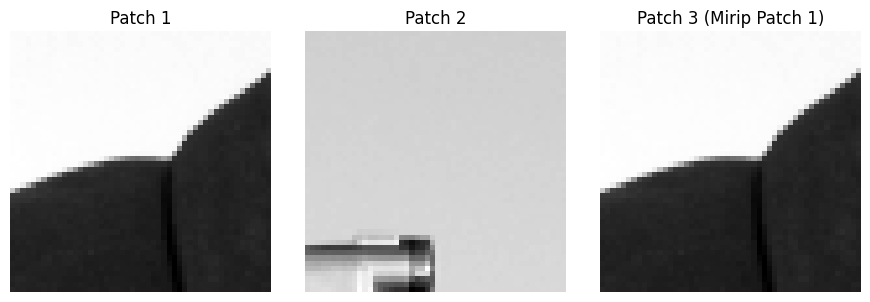

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from scipy.spatial import distance


# 1. Ambil citra dan buat beberapa patch
image = img_as_float(data.camera())

patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]   # Patch dari lokasi berbeda

# Patch 3 = Patch 1 dengan sedikit perubahan intensitas/noise
patch3 = patch1 + 0.1
patch3 = np.clip(patch3, 0, 1)     # Pastikan nilai tetap dalam rentang [0, 1]


# 2. Ubah patch menjadi vektor 1 dimensi
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()


# 3. Hitung jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)


# 4. Hitung jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)


# 5. Tampilkan hasil perhitungan
print(f"Jarak Euclidean antara Patch 1 dan Patch 2 : {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3 : {dist_l2_13:.4f}")

print(f"Jarak Manhattan antara Patch 1 dan Patch 2 : {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3 : {dist_l1_13:.4f}")


# 6. Visualisasi patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Cosine Similarity Image 1 vs Image 2 : 0.8156
Cosine Similarity Image 1 vs Image 3 : 1.0000
Cosine Similarity Image 1 vs Image 4 : 1.0000


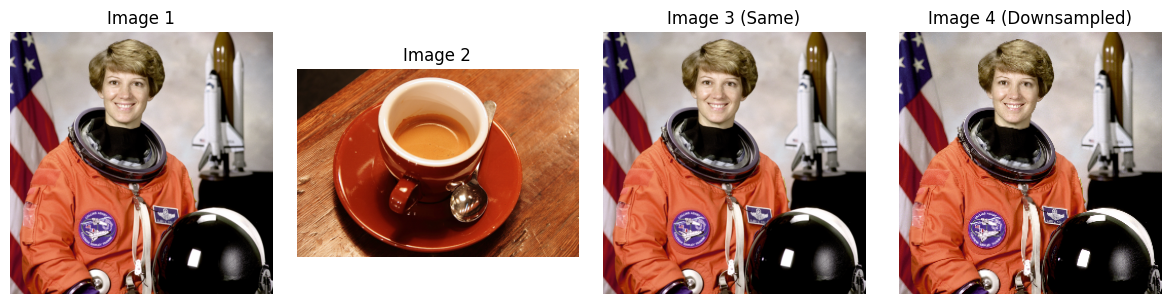

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_ubyte
from scipy.spatial import distance


# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    # Histogram channel merah (R)
    hist_r, _ = np.histogram(
        img_uint8[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram channel hijau (G)
    hist_g, _ = np.histogram(
        img_uint8[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram channel biru (B)
    hist_b, _ = np.histogram(
        img_uint8[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Gabungkan histogram RGB menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi histogram
    hist_combined = hist_combined.astype(float)
    hist_combined /= np.sum(hist_combined)

    return hist_combined


# 1. Memuat citra
try:
    image1 = data.astronaut()
    image2 = data.coffee()            # Citra berbeda
    image3 = data.astronaut()         # Citra sama
    image4 = image1[::2, ::2, :]     # Versi downsampled

except Exception as e:
    print(f"Gagal memuat data skimage: {e}")

    # Membuat citra dummy jika gagal
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]


# 2. Hitung histogram masing-masing citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)


# 3. Hitung cosine similarity
# distance.cosine menghasilkan cosine distance
# sehingga similarity = 1 - distance

sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)


# 4. Tampilkan hasil
print(f"Cosine Similarity Image 1 vs Image 2 : {sim_12:.4f}")
print(f"Cosine Similarity Image 1 vs Image 3 : {sim_13:.4f}")
print(f"Cosine Similarity Image 1 vs Image 4 : {sim_14:.4f}")


# 5. Visualisasi citra
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title("Image 1")
axes[0].axis("off")

axes[1].imshow(image2)
axes[1].set_title("Image 2")
axes[1].axis("off")

axes[2].imshow(image3)
axes[2].set_title("Image 3 (Same)")
axes[2].axis("off")

axes[3].imshow(image4)
axes[3].set_title("Image 4 (Downsampled)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

SSIM (Reference vs Same)      : 1.0000
SSIM (Reference vs Noisy)     : 0.2954
SSIM (Reference vs Contrast)  : 0.9651
SSIM (Reference vs Blurred)   : 0.8027


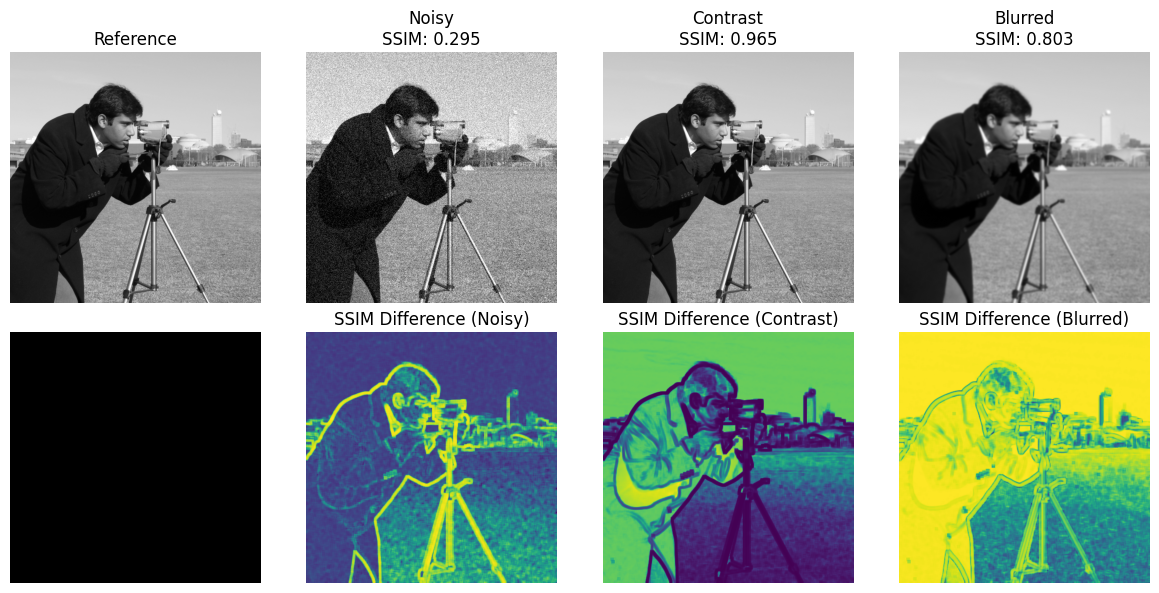

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian


# 1. Memuat citra referensi
image_ref = img_as_float(data.camera())


# 2. Membuat beberapa versi citra terdistorsi

# a. Citra yang sama
image_same = image_ref.copy()

# b. Citra dengan noise Gaussian
image_noisy = random_noise(
    image_ref,
    mode='gaussian',
    var=0.01
)

# c. Citra dengan perubahan kontras
image_contrast = np.clip(image_ref * 0.8, 0, 1)

# d. Citra yang di-blur
image_blurred = gaussian(
    image_ref,
    sigma=1.5,
    channel_axis=None
)


# 3. Hitung nilai SSIM
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(
    image_ref,
    image_same,
    data_range=data_range,
    full=True
)

ssim_noisy, diff_noisy = ssim(
    image_ref,
    image_noisy,
    data_range=data_range,
    full=True
)

ssim_contrast, diff_contrast = ssim(
    image_ref,
    image_contrast,
    data_range=data_range,
    full=True
)

ssim_blurred, diff_blurred = ssim(
    image_ref,
    image_blurred,
    data_range=data_range,
    full=True
)


# 4. Tampilkan hasil SSIM
print(f"SSIM (Reference vs Same)      : {ssim_same:.4f}")
print(f"SSIM (Reference vs Noisy)     : {ssim_noisy:.4f}")
print(f"SSIM (Reference vs Contrast)  : {ssim_contrast:.4f}")
print(f"SSIM (Reference vs Blurred)   : {ssim_blurred:.4f}")


# 5. Visualisasi hasil
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()


# Baris pertama: citra
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')


# Baris kedua: peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Difference (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Difference (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Difference (Blurred)')
ax[7].axis('off')


plt.tight_layout()
plt.show()

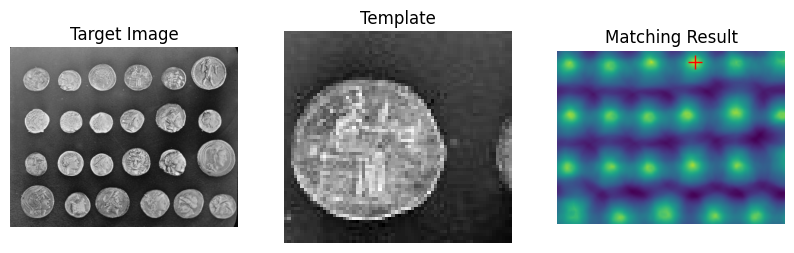

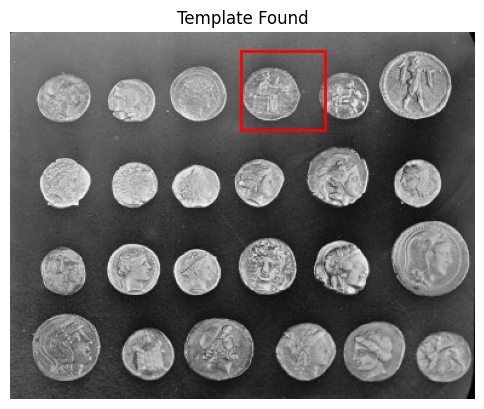

Template ditemukan di koordinat (x, y): (190, 15)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template


# 1. Memuat citra target
image = data.coins()

# Mengambil salah satu bagian citra sebagai template
template = image[15:80, 190:260]


# 2. Melakukan template matching
# Menggunakan metode Normalized Cross-Correlation
result = match_template(image, template)


# 3. Menentukan lokasi dengan nilai kecocokan tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)

# Koordinat posisi template
x, y = ij[::-1]


# 4. Visualisasi citra dan hasil matching
fig, ax = plt.subplots(1, 3, figsize=(10, 4))


# Citra target
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')


# Template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')


# Heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result')
ax[2].axis('off')

# Menandai titik dengan kecocokan terbaik
ax[2].plot(x, y, 'r+', markersize=10)


# 5. Menampilkan lokasi template pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))

ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.axis('off')

# Ukuran template
h, w = template.shape

# Membuat kotak pada lokasi template
rect = plt.Rectangle(
    (x, y),
    w,
    h,
    edgecolor='red',
    facecolor='none',
    linewidth=2
)

ax_main.add_patch(rect)

plt.show()


# 6. Menampilkan koordinat hasil pencarian
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

Memproses database citra...

- astronaut berhasil diproses
- camera berhasil diproses
- coffee berhasil diproses
- coins berhasil diproses
- chelsea berhasil diproses

Hasil Retrieval:
(Semakin kecil distance, semakin mirip)

Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


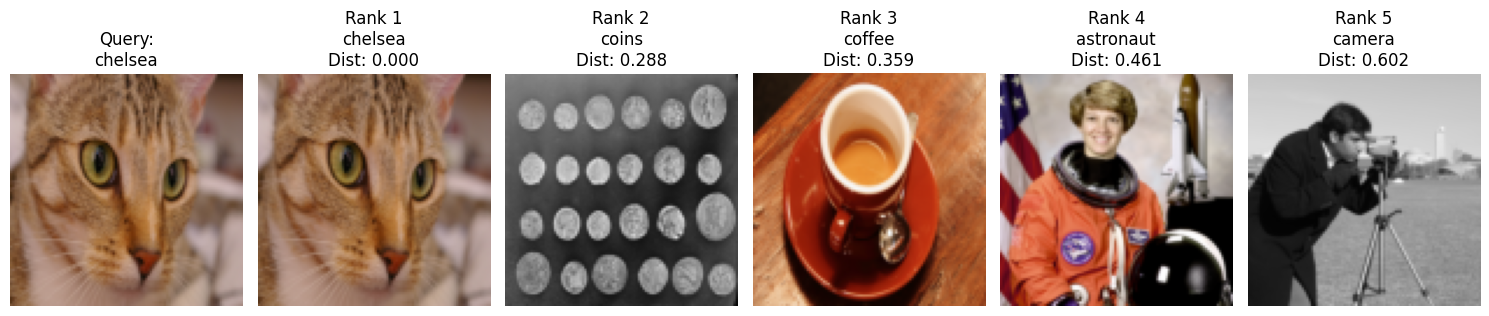

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import (
    data,
    color,
    transform,
    img_as_ubyte
)

from scipy.spatial import distance


# Fungsi untuk menghitung histogram RGB
def calculate_rgb_histogram(image, bins=16):

    # Konversi citra float [0,1] menjadi uint8 [0,255]
    if image.dtype == float:
        image = img_as_ubyte(image)

    # Histogram channel merah
    hist_r, _ = np.histogram(
        image[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram channel hijau
    hist_g, _ = np.histogram(
        image[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram channel biru
    hist_b, _ = np.histogram(
        image[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Gabungkan histogram RGB
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi histogram
    hist_sum = np.sum(hist_combined)

    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined


# 1. Menyiapkan database citra
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_hists = []

print("Memproses database citra...\n")

for name in image_db_names:

    try:
        # Memuat citra
        img = getattr(data, name)()

        # Jika grayscale, ubah menjadi RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar ukuran konsisten
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        # Simpan citra dan histogram
        database_images.append(img_resized)
        database_hists.append(
            calculate_rgb_histogram(img_resized)
        )

        print(f"- {name} berhasil diproses")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# 2. Menentukan citra query
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_hist = database_hists[query_index]


# 3. Hitung cosine distance terhadap semua citra
distances = []

for hist in database_hists:

    dist = distance.cosine(query_hist, hist)
    distances.append(dist)


# 4. Urutkan berdasarkan jarak terkecil
sorted_indices = np.argsort(distances)


# 5. Visualisasi hasil retrieval
num_results = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results + 1,
    figsize=(15, 3)
)


# Menampilkan query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_image_name}")
axes[0].axis("off")


print("\nHasil Retrieval:")
print("(Semakin kecil distance, semakin mirip)\n")


# Menampilkan hasil retrieval
for i, idx in enumerate(sorted_indices):

    rank = i + 1

    axes[rank].imshow(database_images[idx])

    axes[rank].set_title(
        f"Rank {rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    axes[rank].axis("off")

    print(
        f"Rank {rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )


plt.tight_layout()
plt.show()

Memproses database citra...

- astronaut berhasil diproses
- camera berhasil diproses
- coffee berhasil diproses
- coins berhasil diproses
- chelsea berhasil diproses

Hasil Retrieval:
(Semakin kecil distance, semakin mirip)

Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


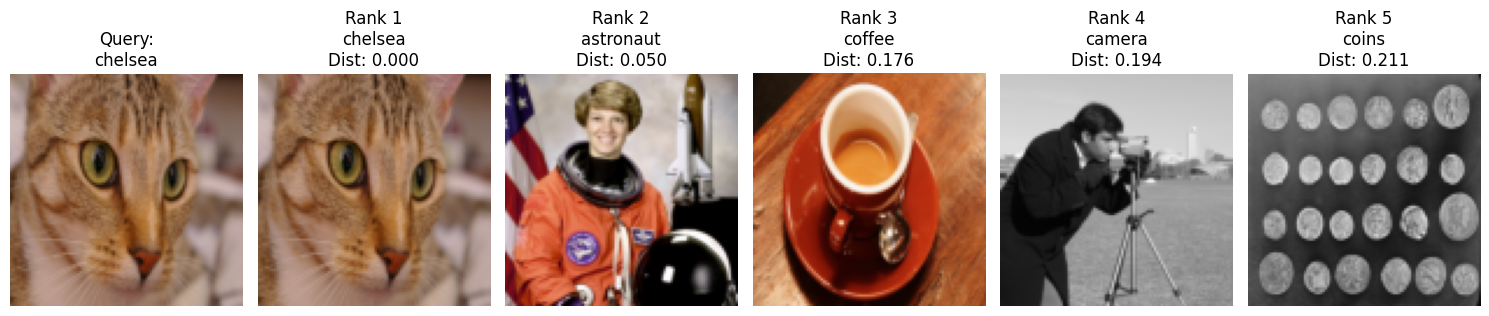

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import (
    data,
    color,
    transform
)

from scipy.spatial import distance


# =========================================================
# Fungsi menghitung fitur Mean RGB
# =========================================================
def calculate_mean_rgb(image):

    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])

    return np.array([mean_r, mean_g, mean_b])


# =========================================================
# 1. Menyiapkan database citra
# =========================================================
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_features = []

print("Memproses database citra...\n")

for name in image_db_names:

    try:
        # Memuat citra
        img = getattr(data, name)()

        # Jika grayscale → ubah ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar ukuran konsisten
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        # Hitung fitur mean RGB
        feature = calculate_mean_rgb(img_resized)

        database_images.append(img_resized)
        database_features.append(feature)

        print(f"- {name} berhasil diproses")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# =========================================================
# 2. Menentukan query image
# =========================================================
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_feature = database_features[query_index]


# =========================================================
# 3. Hitung Euclidean Distance
# =========================================================
distances = []

for feature in database_features:

    dist = distance.euclidean(
        query_feature,
        feature
    )

    distances.append(dist)


# =========================================================
# 4. Urutkan hasil retrieval
# =========================================================
sorted_indices = np.argsort(distances)


# =========================================================
# 5. Visualisasi hasil retrieval
# =========================================================
num_results = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results + 1,
    figsize=(15, 3)
)


# Menampilkan query image
axes[0].imshow(query_image)

axes[0].set_title(
    f"Query:\n{query_image_name}"
)

axes[0].axis("off")


print("\nHasil Retrieval:")
print("(Semakin kecil distance, semakin mirip)\n")


# Menampilkan hasil retrieval
for i, idx in enumerate(sorted_indices):

    rank = i + 1

    axes[rank].imshow(
        database_images[idx]
    )

    axes[rank].set_title(
        f"Rank {rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    axes[rank].axis("off")

    print(
        f"Rank {rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )


plt.tight_layout()
plt.show()


Skor template asli     : 1.0000
Skor template rotasi   : 0.6059
Skor template skala    : 0.6072


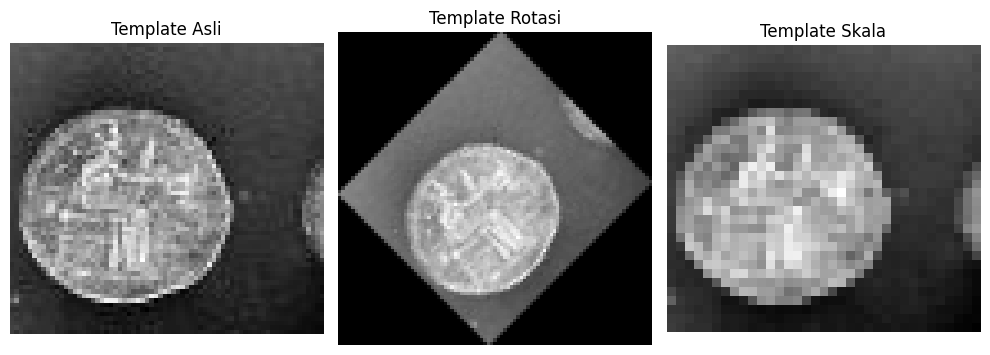

In [2]:
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale
import numpy as np


# 1. Memuat citra
image = data.coins()

# Template asli
template = image[15:80, 190:260]

# Template diputar
template_rotated = rotate(
    template,
    angle=45,
    resize=True
)

# Template diubah skala
template_scaled = rescale(
    template,
    scale=0.5,
    anti_aliasing=True
)


# 2. Template matching
result_original = match_template(
    image,
    template
)

result_rotated = match_template(
    image,
    template_rotated
)

result_scaled = match_template(
    image,
    template_scaled
)


# 3. Ambil skor maksimum
score_original = np.max(result_original)
score_rotated = np.max(result_rotated)
score_scaled = np.max(result_scaled)


# 4. Tampilkan hasil
print(f"Skor template asli     : {score_original:.4f}")
print(f"Skor template rotasi   : {score_rotated:.4f}")
print(f"Skor template skala    : {score_scaled:.4f}")


# 5. Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(template, cmap='gray')
axes[0].set_title("Template Asli")
axes[0].axis("off")

axes[1].imshow(template_rotated, cmap='gray')
axes[1].set_title("Template Rotasi")
axes[1].axis("off")

axes[2].imshow(template_scaled, cmap='gray')
axes[2].set_title("Template Skala")
axes[2].axis("off")

plt.tight_layout()
plt.show()